In [1]:
import os

import numpy as np
np.set_printoptions(suppress=True)
import pandas as pd
from sklearn import linear_model
from sklearn.metrics import mean_squared_error, r2_score

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import (LinearLocator, MultipleLocator, FormatStrFormatter)
from matplotlib.dates import MONDAY
from matplotlib.dates import MonthLocator, WeekdayLocator, DateFormatter
from matplotlib import gridspec
from pandas.plotting import register_matplotlib_converters
register_matplotlib_converters()
%matplotlib inline

print("Package is ready.")

Package is ready.


In [2]:
plt.rcParams['figure.figsize'] = ((8/2.54), (6/2.54))
plt.rcParams["font.family"] = "Arial"
plt.rcParams["mathtext.default"] = "rm"
plt.rcParams.update({'font.size': 11})
MARKER_SIZE = 15
cmap_m = ["#f4a6ad", "#f6957e", "#fccfa2", "#8de7be", "#86d6f2", "#24a9e4", "#b586e0", "#d7f293"]
cmap = ["#e94d5b", "#ef4d28", "#f9a54f", "#25b575", "#1bb1e7", "#1477a2", "#a662e5", "#c2f442"]

plt.rcParams['axes.spines.top'] = False
# plt.rcParams['axes.edgecolor'] = 
plt.rcParams['axes.linewidth'] = 1
plt.rcParams['lines.linewidth'] = 1.5
plt.rcParams['xtick.major.width'] = 1
plt.rcParams['xtick.minor.width'] = 1
plt.rcParams['ytick.major.width'] = 1
plt.rcParams['ytick.minor.width'] = 1

In [3]:
def make_patch_spines_invisible(ax):
    ax.set_frame_on(True)
    ax.patch.set_visible(False)
    for sp in ax.spines.values():
        sp.set_visible(False)

# Figure 2A

### Data collection period

In [4]:
DIRECTORY = './env_set/'
file_list = os.listdir(DIRECTORY)
dataset_list = [file for file in file_list if file.endswith('.csv')]
dataset_list.sort()

In [5]:
date_indices = []
for FILENAME in dataset_list:
    env_df = pd.read_csv(DIRECTORY + FILENAME, index_col=['MEAS_DATE']).dropna(how='all')
    env_df.index = pd.DatetimeIndex(env_df.index)
    date_indices.append([env_df.index[0], env_df.index[-1]])
date_indices = np.array(date_indices)

In [6]:
date_indices.min()

Timestamp('2017-01-01 00:00:00')

In [7]:
date_indices.max()

Timestamp('2019-05-04 23:00:00')

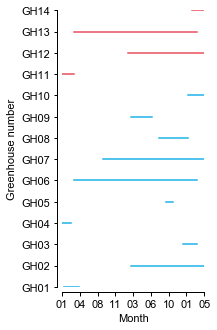

In [8]:
# maximum_x_values = pd.date_range(date_indices.min(), date_indices.max())
fig = plt.figure(figsize=((8/2.54), (6/2.54)*2))
ax0 = plt.subplot()
i = 1
for DATES, ID in zip(date_indices, dataset_list):
    x_values = pd.date_range(DATES[0], DATES[-1])
    if i <11:
        ax0.plot(DATES, ['GH' + ('%02d' % i)]*len(DATES), c=cmap[4])
    else:
        ax0.plot(DATES, ['GH' + ('%02d' % i)]*len(DATES), c=cmap[0])
    i += 1

ax0.spines['right'].set_visible(False)
ax0.spines['left'].set_position(('outward', 5))
ax0.spines['bottom'].set_position(('outward', 5))

ax0.xaxis.set_major_locator(LinearLocator(9))
ax0.xaxis.set_major_formatter(mdates.DateFormatter('%m'))
ax0.set_xbound(date_indices.min(), date_indices.max() + pd.Timedelta('1h'))

ax0.set_xlabel('Month')
ax0.set_ylabel('Greenhouse number')
ax0.set_ybound('GH01', 'GH14')


fig.tight_layout()
fig.savefig('./figures/Fig2A.svg', transparent=True, format='svg')
plt.show() 

# Figure 2B

### Data collection period

In [9]:
DIRECTORY = './env_set/tom_env/'
file_list = os.listdir(DIRECTORY)
dataset_list = [file for file in file_list if file.endswith('.csv')]
dataset_list.sort()

In [10]:
date_indices = []
for FILENAME in dataset_list:
    env_df = pd.read_csv(DIRECTORY + FILENAME, index_col=['MEAS_DATE']).dropna(how='all')
    env_df.index = pd.DatetimeIndex(env_df.index)
    date_indices.append([env_df.index[0], env_df.index[-1]])
date_indices = np.array(date_indices)

In [11]:
date_indices.min()

Timestamp('2017-01-01 00:00:00')

In [12]:
date_indices.max()

Timestamp('2019-05-04 23:00:00')

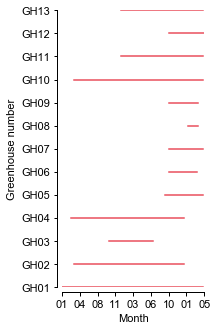

In [13]:
# maximum_x_values = pd.date_range(date_indices.min(), date_indices.max())
fig = plt.figure(figsize=((8/2.54), (6/2.54)*2))
ax0 = plt.subplot()
i = 1
for DATES, ID in zip(date_indices, dataset_list):
    x_values = pd.date_range(DATES[0], DATES[-1])
    ax0.plot(DATES, ['GH' + ('%02d' % i)]*len(DATES), c=cmap[0])
    i += 1

ax0.spines['right'].set_visible(False)
ax0.spines['left'].set_position(('outward', 5))
ax0.spines['bottom'].set_position(('outward', 5))

ax0.xaxis.set_major_locator(LinearLocator(9))
ax0.xaxis.set_major_formatter(mdates.DateFormatter('%m'))
ax0.set_xbound(date_indices.min(), date_indices.max() + pd.Timedelta('1h'))

ax0.set_xlabel('Month')
ax0.set_ylabel('Greenhouse number')
ax0.set_ybound('GH01', 'GH13')


fig.tight_layout()
fig.savefig('./figures/Fig2B.svg', transparent=True, format='svg')
plt.show() 

# Figure 3A

### A monthly summary of solar radiation and outside temperature

In [14]:
DIRECTORY = './env_set/'
file_list = os.listdir(DIRECTORY)
dataset_list = [file for file in file_list if file.endswith('.csv')]
dataset_list.sort()

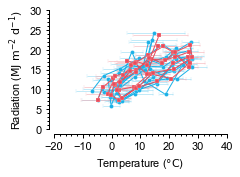

In [15]:
fig = plt.figure(figsize=((8/2.54)*1.1, (6/2.54)*1.1))
ax0 = plt.subplot()
ax0.spines['right'].set_visible(False)
ax0.spines['left'].set_position(('outward', 5))
ax0.spines['bottom'].set_position(('outward', 5))

i=0
for FILENAME in dataset_list:
    env_df = pd.read_csv(DIRECTORY + FILENAME, index_col=['MEAS_DATE']).dropna(how='all')
    env_df = env_df[~(env_df == 0).all(axis=1)].interpolate()
    
    env_df.index = pd.DatetimeIndex(env_df.index)
    avg_temp = env_df['T_out'].resample('D').mean()
    min_temp = env_df['T_out'].resample('D').min()
    max_temp = env_df['T_out'].resample('D').max()
    daily_rad = env_df['Rad'].resample('D').sum()*3600/1e6 # MJ m-2 d-1

    env_avg_df = pd.concat([min_temp, max_temp, avg_temp, daily_rad], axis=1)
    env_avg_df.columns = ['T_min', 'T_max', 'T_avg', 'Rad_day']
    env_avg_df = env_avg_df.resample('M').mean()
    minmax = pd.concat([env_avg_df['T_avg']-env_avg_df['T_min'], env_avg_df['T_max']-env_avg_df['T_avg']], axis=1).T.values
    if FILENAME[:3] == 'Val':
        ax0.errorbar(env_avg_df['T_avg'], env_avg_df['Rad_day'],
                     xerr=minmax, ecolor=cmap_m[0], elinewidth=0.5, capsize=2, capthick=0.5,
                     c=cmap[0], lw=1, marker='s', markersize=4, mec='white', mew=0.2)
    else:
        ax0.errorbar(env_avg_df['T_avg'], env_avg_df['Rad_day'],
                     xerr=minmax, ecolor=cmap_m[4], elinewidth=0.5, capsize=2, capthick=0.5,
                     c=cmap[4], lw=1, marker='o', markersize=4, mec='white', mew=0.2)
    i += 1

ax0.xaxis.set_major_locator(LinearLocator(7))
ax0.xaxis.set_minor_locator(LinearLocator(31))
ax0.yaxis.set_major_locator(LinearLocator(7))
ax0.yaxis.set_minor_locator(LinearLocator(31))

ax0.set_xbound(-20, 40)
ax0.set_ybound(0, 30)

ax0.set_xlabel('Temperature ($°C$)')
ax0.set_ylabel('Radiation ($MJ\ m^{-2}\ d^{-1}$)')

fig.tight_layout()
fig.savefig('./figures/Fig3A.svg', transparent=True, format='svg')
plt.show() 

# Figure 3B

### A monthly summary of solar radiation and outside temperature

In [16]:
DIRECTORY = './env_set/tom_env/'
file_list = os.listdir(DIRECTORY)
dataset_list = [file for file in file_list if file.endswith('.csv')]
dataset_list.sort()

In [17]:
dataset_list

['PFS_0000008_tom_env.csv',
 'PF_0000227_tom_env.csv',
 'PF_0000304_tom_env.csv',
 'PF_0001405_tom_env.csv',
 'PF_0002525_tom_env.csv',
 'PF_0002526_tom_env.csv',
 'PF_0002527_tom_env.csv',
 'PF_0002529_tom_env.csv',
 'PF_0002533_tom_env.csv',
 'Val_PF_0001396_tom_env.csv',
 'Val_PF_0002528_tom_env.csv',
 'Val_PF_0002531_tom_env.csv',
 'Val_PF_0002532_tom_env.csv']

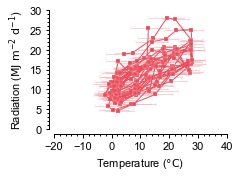

In [18]:
fig = plt.figure(figsize=((8/2.54)*1.1, (6/2.54)*1.1))
ax0 = plt.subplot()
ax0.spines['right'].set_visible(False)
ax0.spines['left'].set_position(('outward', 5))
ax0.spines['bottom'].set_position(('outward', 5))

i=0
for FILENAME in dataset_list:
    env_df = pd.read_csv(DIRECTORY + FILENAME, index_col=['MEAS_DATE']).dropna(how='all')
    env_df = env_df[~(env_df == 0).all(axis=1)].interpolate()
    
    env_df.index = pd.DatetimeIndex(env_df.index)
    avg_temp = env_df['T_out'].resample('D').mean()
    min_temp = env_df['T_out'].resample('D').min()
    max_temp = env_df['T_out'].resample('D').max()
    daily_rad = env_df['Rad'].resample('D').sum()*3600/1e6 # MJ m-2 d-1

    env_avg_df = pd.concat([min_temp, max_temp, avg_temp, daily_rad], axis=1)
    env_avg_df.columns = ['T_min', 'T_max', 'T_avg', 'Rad_day']
    env_avg_df = env_avg_df.resample('M').mean()
    minmax = pd.concat([env_avg_df['T_avg']-env_avg_df['T_min'], env_avg_df['T_max']-env_avg_df['T_avg']], axis=1).T.values
    ax0.errorbar(env_avg_df['T_avg'], env_avg_df['Rad_day'],
                 xerr=minmax, ecolor=cmap_m[0], elinewidth=0.5, capsize=2, capthick=0.5,
                 c=cmap[0], lw=1, marker='s', markersize=4, mec='white', mew=0.2)
    i += 1

ax0.xaxis.set_major_locator(LinearLocator(7))
ax0.xaxis.set_minor_locator(LinearLocator(31))
ax0.yaxis.set_major_locator(LinearLocator(7))
ax0.yaxis.set_minor_locator(LinearLocator(31))

ax0.set_xbound(-20, 40)
ax0.set_ybound(0, 30)

ax0.set_xlabel('Temperature ($°C$)')
ax0.set_ylabel('Radiation ($MJ\ m^{-2}\ d^{-1}$)')

fig.tight_layout()
fig.savefig('./figures/Fig3B.svg', transparent=True, format='svg')
plt.show() 

# Figure 4

### Data range

In [19]:
DIRECTORY = './env_set/'
file_list = os.listdir(DIRECTORY)
dataset_list = [file for file in file_list if file.endswith('.csv')]
dataset_list.sort()

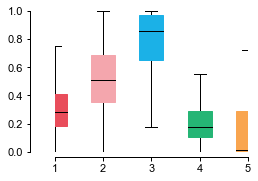

In [20]:
fig = plt.figure(figsize=((8/2.54)*1.1, (6/2.54)*1.1))
ax0 = plt.subplot()
ax0.spines['right'].set_visible(False)
ax0.spines['left'].set_position(('outward', 25))
ax0.spines['bottom'].set_position(('outward', 5))
#labels = ['$Temp_{in}$', '$Temp_{out}$', 'RH', '$CO_2$', 'Rad']
temp = []
for FILENAME in dataset_list[:-1]:
    env_df = pd.read_csv(DIRECTORY + FILENAME, index_col=['MEAS_DATE']).dropna(how='all')
    env_df.index = pd.DatetimeIndex(env_df.index)
    env_df = env_df[~(env_df == 0).all(axis=1)].interpolate()
    env_df = env_df.resample('H').mean()
    env_df = env_df.interpolate()
    temp.append(((env_df - env_df.min())/(env_df.max() - env_df.min())).values)
    
temp = np.concatenate(temp, axis = 0)
bplot = ax0.boxplot(temp, vert=True, showfliers=False, patch_artist=True, medianprops=dict(color='k'))

cmap_temp = [cmap[0], cmap_m[0], cmap[4], cmap[3], cmap[2]]
for patch, color in zip(bplot['boxes'], cmap_temp):
        patch.set_facecolor(color)
        patch.set_color(color)

ax0.set_ybound([0, 1])
ax0.set_xbound([1, 5])

fig.savefig('./figures/Fig4.svg', transparent=True, format='svg')

# Figure 5

### R2 & RMSE

In [21]:
test_label = pd.read_csv('./results/test_label.csv', index_col='Unnamed: 0')
mlp_pred = pd.read_csv('./results/mlp_pred.csv', index_col='Unnamed: 0')
lstm_pred = pd.read_csv('./results/lstm_pred.csv', index_col='Unnamed: 0')
bilstm_pred = pd.read_csv('./results/bilstm_pred.csv', index_col='Unnamed: 0')
ae_lstm_pred = pd.read_csv('./results/ae_lstm_pred.csv', index_col='Unnamed: 0')
ae_bilstm_pred = pd.read_csv('./results/ae_bilstm_pred.csv', index_col='Unnamed: 0')
pred_results = [mlp_pred, lstm_pred, bilstm_pred, ae_lstm_pred, ae_bilstm_pred]

In [22]:
r2_scores = []
for pred_ in pred_results:
    temp = []
    for i in range(5):
        temp.append(r2_score(test_label.values[..., i], pred_.values[..., i]))
    r2_scores.append(temp)
r2_scores = np.array(r2_scores)

RMSEs = []
for pred_ in pred_results:
    temp = []
    for i in range(5):
        temp.append(np.sqrt(mean_squared_error(test_label.values[..., i], pred_.values[..., i])))
    RMSEs.append(temp)
RMSEs = np.array(RMSEs)

In [23]:
r2_scores

array([[0.71912963, 0.83303927, 0.71043611, 0.4728543 , 0.61530474],
       [0.75773732, 0.87627036, 0.72949308, 0.46127541, 0.64900083],
       [0.75523477, 0.84008743, 0.73898834, 0.51576413, 0.61866564],
       [0.79371492, 0.838735  , 0.59979652, 0.44062793, 0.64473497],
       [0.7267562 , 0.86831407, 0.45951733, 0.39547563, 0.65308329]])

In [24]:
r2_scores.mean(axis=1)

array([0.67015281, 0.6947554 , 0.69374806, 0.66352187, 0.6206293 ])

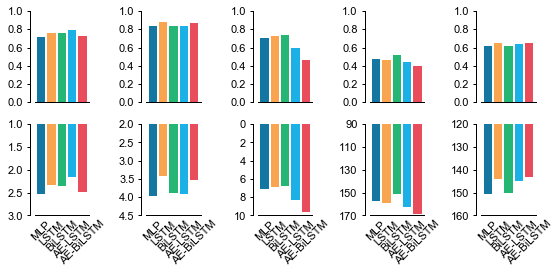

In [25]:
x_t = ['MLP', 'LSTM', 'BiLSTM', 'AE-LSTM', 'AE-BiLSTM']
fig = plt.figure(figsize=((8/2.54)*3*2.5/3, (6/2.54)*2*2.5/3))
grid = plt.GridSpec(2,5)
for _ in range(5):
    ax0 = plt.subplot(grid[_])
    ax0.spines['right'].set_visible(False)
    ax0.spines['left'].set_position(('outward', 5))
    ax0.axes.xaxis.set_ticklabels([])
    ax0.tick_params(axis='x', length=0)
    
    expect1 = ax0.bar(x_t, r2_scores[:, _], width=0.8, color=[cmap[5], cmap[2], cmap[3], cmap[4], cmap[0]])

    ax0.set_ybound([0, 1])
    ax0.yaxis.set_major_locator(LinearLocator(6))
    plt.xticks(rotation=45)

bounds = [[1, 3], [2, 4.5], [0, 10], [90, 170], [120, 160]]
loc = [5, 6, 6, 5, 5]
for _ in range(5): 
    ax0 = plt.subplot(grid[_+5])
    ax0.spines['right'].set_visible(False)
    ax0.spines['left'].set_position(('outward', 5))
    ax0.tick_params(axis='x', length=0)
    expect1 = ax0.bar(x_t, RMSEs[:, _], width=0.8, color=[cmap[5], cmap[2], cmap[3], cmap[4], cmap[0]])

    ax0.yaxis.set_major_locator(LinearLocator(loc[_]))
    ax0.set_ybound(bounds[_])
    ax0.invert_yaxis()
    plt.xticks(rotation=45)
    
fig.tight_layout()
fig.savefig('./figures/Fig5-1.svg', transparent=True, format='svg')
plt.show()

# Figure 5

### Best and worst cases

In [26]:
LENGTH = 24
mlp_r2 = {}
lstm_r2 = {}
bilstm_r2 = {}
aelstm_r2 = {}
aebilstm_r2 = {}
mlp_rmse = {}
lstm_rmse = {}
bilstm_rmse = {}
aelstm_rmse = {}
aebilstm_rmse = {}
x_t = np.arange(0, LENGTH)

NUMBERS = np.arange(1, int(bilstm_pred.shape[0]/LENGTH))
#     np.random.shuffle(NUMBERS)
#     NUMBERS = NUMBERS[:6]

for NUMBER in NUMBERS:
    r2 = r2_score(test_label.values[NUMBER*24:NUMBER*24+LENGTH, :].reshape(-1, 1),
                  mlp_pred.values[NUMBER*24:NUMBER*24+LENGTH, :].reshape(-1, 1))
    rmse = np.sqrt(mean_squared_error(test_label.values[NUMBER*24:NUMBER*24+LENGTH, :].reshape(-1, 1),
                                      mlp_pred.values[NUMBER*24:NUMBER*24+LENGTH, :].reshape(-1, 1)))
    mlp_r2[NUMBER] = r2
    mlp_rmse[NUMBER] = rmse    
    
    r2 = r2_score(test_label.values[NUMBER*24:NUMBER*24+LENGTH, :].reshape(-1, 1),
                  lstm_pred.values[NUMBER*24:NUMBER*24+LENGTH, :].reshape(-1, 1))
    rmse = np.sqrt(mean_squared_error(test_label.values[NUMBER*24:NUMBER*24+LENGTH, :].reshape(-1, 1),
                                      lstm_pred.values[NUMBER*24:NUMBER*24+LENGTH, :].reshape(-1, 1)))
    lstm_r2[NUMBER] = r2
    lstm_rmse[NUMBER] = rmse
    
    r2 = r2_score(test_label.values[NUMBER*24:NUMBER*24+LENGTH, :].reshape(-1, 1),
                  bilstm_pred.values[NUMBER*24:NUMBER*24+LENGTH, :].reshape(-1, 1))
    rmse = np.sqrt(mean_squared_error(test_label.values[NUMBER*24:NUMBER*24+LENGTH, :].reshape(-1, 1),
                                      bilstm_pred.values[NUMBER*24:NUMBER*24+LENGTH, :].reshape(-1, 1)))
    bilstm_r2[NUMBER] = r2
    bilstm_rmse[NUMBER] = rmse

    r2 = r2_score(test_label.values[NUMBER*24:NUMBER*24+LENGTH, :].reshape(-1, 1),
                  ae_lstm_pred.values[NUMBER*24:NUMBER*24+LENGTH, :].reshape(-1, 1))
    rmse = np.sqrt(mean_squared_error(test_label.values[NUMBER*24:NUMBER*24+LENGTH, :].reshape(-1, 1),
                                      ae_lstm_pred.values[NUMBER*24:NUMBER*24+LENGTH, :].reshape(-1, 1)))
    aelstm_r2[NUMBER] = r2
    aelstm_rmse[NUMBER] = rmse    
    
    r2 = r2_score(test_label.values[NUMBER*24:NUMBER*24+LENGTH, :].reshape(-1, 1),
                  ae_bilstm_pred.values[NUMBER*24:NUMBER*24+LENGTH, :].reshape(-1, 1))
    rmse = np.sqrt(mean_squared_error(test_label.values[NUMBER*24:NUMBER*24+LENGTH, :].reshape(-1, 1),
                                      ae_bilstm_pred.values[NUMBER*24:NUMBER*24+LENGTH, :].reshape(-1, 1)))
    aebilstm_r2[NUMBER] = r2
    aebilstm_rmse[NUMBER] = rmse

In [27]:
for i in range(14554, 14606):
    del(mlp_rmse[i])
    del(mlp_r2[i])
    
del(aelstm_rmse[7431])
del(aelstm_r2[7431])
del(aelstm_rmse[2323])
del(aelstm_r2[2323])

for i in range(13950,14111):
    del(aebilstm_rmse[i])
    del(aebilstm_r2[i])

In [28]:
print(min(mlp_rmse, key=mlp_rmse.get))
print(min(lstm_rmse, key=lstm_rmse.get))
print(min(bilstm_rmse, key=bilstm_rmse.get))
print(min(aelstm_rmse, key=aelstm_rmse.get))
print(min(aebilstm_rmse, key=aebilstm_rmse.get))

9581
7756
8249
2324
8147


In [29]:
print(max(mlp_r2, key=mlp_r2.get))
print(max(lstm_r2, key=lstm_r2.get))
print(max(bilstm_r2, key=bilstm_r2.get))
print(max(aelstm_r2, key=aelstm_r2.get))
print(max(aebilstm_r2, key=aebilstm_r2.get))

9581
7756
12029
4872
8147


In [30]:
print(min(mlp_r2, key=mlp_r2.get))
print(min(lstm_r2, key=lstm_r2.get))
print(min(bilstm_r2, key=bilstm_r2.get))
print(min(aelstm_r2, key=aelstm_r2.get))
print(min(aebilstm_r2, key=aebilstm_r2.get))

7407
7407
744
7413
3283


In [31]:
print(max(mlp_rmse, key=mlp_rmse.get))
print(max(lstm_rmse, key=lstm_rmse.get))
print(max(bilstm_rmse, key=bilstm_rmse.get))
print(max(aelstm_rmse, key=aelstm_rmse.get))
print(max(aebilstm_rmse, key=aebilstm_rmse.get))

14968
15056
14972
14967
15056


In [32]:
LENGTH = 24
x_t = np.arange(0, LENGTH)
MIN_NUMBERS = [min(mlp_rmse, key=mlp_rmse.get), min(lstm_rmse, key=lstm_rmse.get), min(bilstm_rmse, key=bilstm_rmse.get), min(aelstm_rmse, key=aelstm_rmse.get), min(aebilstm_rmse, key=aebilstm_rmse.get)]
MAX_NUMBERS = [max(mlp_rmse, key=mlp_rmse.get), max(lstm_rmse, key=lstm_rmse.get), max(bilstm_rmse, key=bilstm_rmse.get), max(aelstm_rmse, key=aelstm_rmse.get), max(aebilstm_rmse, key=aebilstm_rmse.get)]

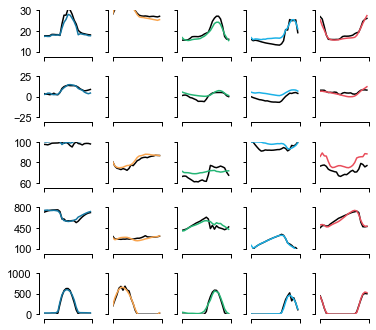

In [33]:
fig = plt.figure(figsize=((8/2.54)*1.7, (6/2.54)*2))
grid = plt.GridSpec(5,5)
Y_BOUNDS = [[10, 30], [-25, 25], [60, 100], [100, 800], [0, 1000]]

for _ in range (5):
    ax = plt.subplot(grid[5*_])
    measured1 = ax.plot(x_t, test_label.values[MIN_NUMBERS[0]*24:MIN_NUMBERS[0]*24+LENGTH, _], c='k')
    expect1 = ax.plot(x_t, mlp_pred.values[MIN_NUMBERS[0]*24:MIN_NUMBERS[0]*24+LENGTH, _], c=cmap[5])
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_position(('outward', 5))
    ax.spines['bottom'].set_position(('outward', 5))
    ax.set_xbound([0, 24])
    ax.set_ybound(Y_BOUNDS[_])
    ax.xaxis.set_major_locator(LinearLocator(2))
    ax.yaxis.set_major_locator(LinearLocator(3))
    ax.axes.xaxis.set_ticklabels([])
    
    ax = plt.subplot(grid[5*_+1])
    measured2 = ax.plot(x_t, test_label.values[MIN_NUMBERS[1]*24:MIN_NUMBERS[1]*24+LENGTH, _], c='k')
    expect2 = ax.plot(x_t, lstm_pred.values[MIN_NUMBERS[1]*24:MIN_NUMBERS[1]*24+LENGTH, _], c=cmap[2])
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_position(('outward', 5))
    ax.spines['left'].set_position(('outward', 5))
    ax.axes.yaxis.set_ticklabels([])
    ax.set_xbound([0, 24])
    ax.set_ybound(Y_BOUNDS[_])
    ax.xaxis.set_major_locator(LinearLocator(2))
    ax.yaxis.set_major_locator(LinearLocator(3))
    ax.axes.xaxis.set_ticklabels([])
    
    ax = plt.subplot(grid[5*_+2])
    measured3 = ax.plot(x_t, test_label.values[MIN_NUMBERS[2]*24:MIN_NUMBERS[2]*24+LENGTH, _], c='k')
    expect3 = ax.plot(x_t, bilstm_pred.values[MIN_NUMBERS[2]*24:MIN_NUMBERS[2]*24+LENGTH, _], c=cmap[3])
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_position(('outward', 5))
    ax.spines['left'].set_position(('outward', 5))
    ax.axes.yaxis.set_ticklabels([])
    ax.set_xbound([0, 24])
    ax.set_ybound(Y_BOUNDS[_])
    ax.xaxis.set_major_locator(LinearLocator(2))
    ax.yaxis.set_major_locator(LinearLocator(3))
    ax.axes.xaxis.set_ticklabels([])
    
    ax = plt.subplot(grid[5*_+3])
    measured4 = ax.plot(x_t, test_label.values[MIN_NUMBERS[3]*24:MIN_NUMBERS[3]*24+LENGTH, _], c='k')
    expect4 = ax.plot(x_t, ae_lstm_pred.values[MIN_NUMBERS[3]*24:MIN_NUMBERS[3]*24+LENGTH, _], c=cmap[4])
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_position(('outward', 5))
    ax.spines['left'].set_position(('outward', 5))
    ax.axes.yaxis.set_ticklabels([])
    ax.set_xbound([0, 24])
    ax.set_ybound(Y_BOUNDS[_])
    ax.xaxis.set_major_locator(LinearLocator(2))
    ax.yaxis.set_major_locator(LinearLocator(3))
    ax.axes.xaxis.set_ticklabels([])
    
    ax = plt.subplot(grid[5*_+4])
    measured5 = ax.plot(x_t, test_label.values[MIN_NUMBERS[4]*24:MIN_NUMBERS[4]*24+LENGTH, _], c='k')
    expect5 = ax.plot(x_t, ae_bilstm_pred.values[MIN_NUMBERS[4]*24:MIN_NUMBERS[4]*24+LENGTH, _], c=cmap[0])
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_position(('outward', 5))
    ax.spines['left'].set_position(('outward', 5))
    ax.axes.yaxis.set_ticklabels([])
    ax.set_xbound([0, 24])
    ax.set_ybound(Y_BOUNDS[_])
    ax.xaxis.set_major_locator(LinearLocator(2))
    ax.yaxis.set_major_locator(LinearLocator(3))
    ax.axes.xaxis.set_ticklabels([])
    
fig.tight_layout()
fig.savefig('./figures/Fig6A.svg', transparent=True, format='svg')
# fig.savefig('./figures/Fig6A.png', transparent=True, dpi=600, format='png')
plt.show()

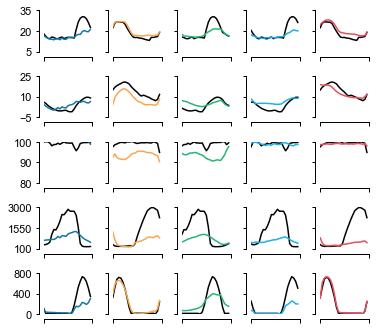

In [34]:
fig = plt.figure(figsize=((8/2.54)*1.7, (6/2.54)*2))
grid = plt.GridSpec(5,5)
Y_BOUNDS = [[5, 35], [-5, 25], [80, 100], [100, 3000], [0, 800]]

for _ in range (5):
    ax = plt.subplot(grid[5*_])
    measured1 = ax.plot(x_t, test_label.values[MAX_NUMBERS[0]*24:MAX_NUMBERS[0]*24+LENGTH, _], c='k')
    expect1 = ax.plot(x_t, mlp_pred.values[MAX_NUMBERS[0]*24:MAX_NUMBERS[0]*24+LENGTH, _], c=cmap[5])
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_position(('outward', 5))
    ax.spines['bottom'].set_position(('outward', 5))
    ax.set_xbound([0, 24])
    ax.set_ybound(Y_BOUNDS[_])
    ax.xaxis.set_major_locator(LinearLocator(2))
    ax.yaxis.set_major_locator(LinearLocator(3))
    ax.axes.xaxis.set_ticklabels([])
    
    ax = plt.subplot(grid[5*_+1])
    measured2 = ax.plot(x_t, test_label.values[MAX_NUMBERS[1]*24:MAX_NUMBERS[1]*24+LENGTH, _], c='k')
    expect2 = ax.plot(x_t, lstm_pred.values[MAX_NUMBERS[1]*24:MAX_NUMBERS[1]*24+LENGTH, _], c=cmap[2])
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_position(('outward', 5))
    ax.spines['left'].set_position(('outward', 5))
    ax.axes.yaxis.set_ticklabels([])
    ax.set_xbound([0, 24])
    ax.set_ybound(Y_BOUNDS[_])
    ax.xaxis.set_major_locator(LinearLocator(2))
    ax.yaxis.set_major_locator(LinearLocator(3))
    ax.axes.xaxis.set_ticklabels([])
    
    ax = plt.subplot(grid[5*_+2])
    measured3 = ax.plot(x_t, test_label.values[MAX_NUMBERS[2]*24:MAX_NUMBERS[2]*24+LENGTH, _], c='k')
    expect3 = ax.plot(x_t, bilstm_pred.values[MAX_NUMBERS[2]*24:MAX_NUMBERS[2]*24+LENGTH, _], c=cmap[3])
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_position(('outward', 5))
    ax.spines['left'].set_position(('outward', 5))
    ax.axes.yaxis.set_ticklabels([])
    ax.set_xbound([0, 24])
    ax.set_ybound(Y_BOUNDS[_])
    ax.xaxis.set_major_locator(LinearLocator(2))
    ax.yaxis.set_major_locator(LinearLocator(3))
    ax.axes.xaxis.set_ticklabels([])
    
    ax = plt.subplot(grid[5*_+3])
    measured4 = ax.plot(x_t, test_label.values[MAX_NUMBERS[3]*24:MAX_NUMBERS[3]*24+LENGTH, _], c='k')
    expect4 = ax.plot(x_t, ae_lstm_pred.values[MAX_NUMBERS[3]*24:MAX_NUMBERS[3]*24+LENGTH, _], c=cmap[4])
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_position(('outward', 5))
    ax.spines['left'].set_position(('outward', 5))
    ax.axes.yaxis.set_ticklabels([])
    ax.set_xbound([0, 24])
    ax.set_ybound(Y_BOUNDS[_])
    ax.xaxis.set_major_locator(LinearLocator(2))
    ax.yaxis.set_major_locator(LinearLocator(3))
    ax.axes.xaxis.set_ticklabels([])
    
    ax = plt.subplot(grid[5*_+4])
    measured5 = ax.plot(x_t, test_label.values[MAX_NUMBERS[4]*24:MAX_NUMBERS[4]*24+LENGTH, _], c='k')
    expect5 = ax.plot(x_t, ae_bilstm_pred.values[MAX_NUMBERS[4]*24:MAX_NUMBERS[4]*24+LENGTH, _], c=cmap[0])
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_position(('outward', 5))
    ax.spines['left'].set_position(('outward', 5))
    ax.axes.yaxis.set_ticklabels([])
    ax.set_xbound([0, 24])
    ax.set_ybound(Y_BOUNDS[_])
    ax.xaxis.set_major_locator(LinearLocator(2))
    ax.yaxis.set_major_locator(LinearLocator(3))
    ax.axes.xaxis.set_ticklabels([])
    
fig.tight_layout()
fig.savefig('./figures/Fig6B.svg', transparent=True, format='svg')
# fig.savefig('./figures/Fig6B.png', transparent=True, dpi=600, format='png')
plt.show()

# Figure 7

### R2 & RMSE

In [35]:
test_label = pd.read_csv('./results/tom_tr_test_label2.csv', index_col='Unnamed: 0')
mlp_pred = pd.read_csv('./results/tom_tr_mlp_pred.csv', index_col='Unnamed: 0')
lstm_pred = pd.read_csv('./results/tom_tr_lstm_pred.csv', index_col='Unnamed: 0')
bilstm_pred = pd.read_csv('./results/tom_tr_bilstm_pred.csv', index_col='Unnamed: 0')
ae_lstm_pred = pd.read_csv('./results/tom_tr_ae_lstm_pred.csv', index_col='Unnamed: 0')
ae_bilstm_pred = pd.read_csv('./results/tom_tr_ae_bilstm_pred.csv', index_col='Unnamed: 0')
pred_results = [mlp_pred, lstm_pred, bilstm_pred, ae_lstm_pred, ae_bilstm_pred]

/home/phil/.virtualenvs/tf20/lib/python3.6/site-packages/numpy/lib/arraysetops.py:569: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  mask |= (ar1 == a)


In [36]:
r2_scores = []
for pred_ in pred_results:
    temp = []
    for i in range(5):
        temp.append(r2_score(test_label.values[..., i], pred_.values[..., i]))
    r2_scores.append(temp)
r2_scores = np.array(r2_scores)

RMSEs = []
for pred_ in pred_results:
    temp = []
    for i in range(5):
        temp.append(np.sqrt(mean_squared_error(test_label.values[..., i], pred_.values[..., i])))
    RMSEs.append(temp)
RMSEs = np.array(RMSEs)

In [37]:
tr_r2_scores = r2_scores
tr_RMSEs = RMSEs

In [38]:
mlp_pred = pd.read_csv('./results/tom_raw_mlp_pred.csv', index_col='Unnamed: 0')
lstm_pred = pd.read_csv('./results/tom_raw_lstm_pred.csv', index_col='Unnamed: 0')
bilstm_pred = pd.read_csv('./results/tom_raw_bilstm_pred.csv', index_col='Unnamed: 0')
ae_lstm_pred = pd.read_csv('./results/tom_raw_ae_lstm_pred.csv', index_col='Unnamed: 0')
ae_bilstm_pred = pd.read_csv('./results/tom_raw_ae_bilstm_pred.csv', index_col='Unnamed: 0')
pred_results = [mlp_pred, lstm_pred, bilstm_pred, ae_lstm_pred, ae_bilstm_pred]

/home/phil/.virtualenvs/tf20/lib/python3.6/site-packages/numpy/lib/arraysetops.py:569: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  mask |= (ar1 == a)


In [39]:
pred_results = [mlp_pred, lstm_pred, bilstm_pred, ae_lstm_pred, ae_bilstm_pred]

In [40]:
r2_scores = []
for pred_ in pred_results:
    temp = []
    for i in range(5):
        temp.append(r2_score(test_label.values[..., i], pred_.values[..., i]))
    r2_scores.append(temp)
r2_scores = np.array(r2_scores)

RMSEs = []
for pred_ in pred_results:
    temp = []
    for i in range(5):
        temp.append(np.sqrt(mean_squared_error(test_label.values[..., i], pred_.values[..., i])))
    RMSEs.append(temp)
RMSEs = np.array(RMSEs)

In [41]:
raw_r2_scores = r2_scores
raw_RMSEs = RMSEs

In [42]:
mlp_pred = pd.read_csv('./results/tom_prev_mlp_pred.csv', index_col='Unnamed: 0')
lstm_pred = pd.read_csv('./results/tom_prev_lstm_pred.csv', index_col='Unnamed: 0')
bilstm_pred = pd.read_csv('./results/tom_prev_bilstm_pred.csv', index_col='Unnamed: 0')
ae_lstm_pred = pd.read_csv('./results/tom_prev_ae_lstm_pred.csv', index_col='Unnamed: 0')
ae_bilstm_pred = pd.read_csv('./results/tom_prev_ae_bilstm_pred.csv', index_col='Unnamed: 0')
pred_results = [mlp_pred, lstm_pred, bilstm_pred, ae_lstm_pred, ae_bilstm_pred]

/home/phil/.virtualenvs/tf20/lib/python3.6/site-packages/numpy/lib/arraysetops.py:569: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  mask |= (ar1 == a)


In [43]:
r2_scores = []
for pred_ in pred_results:
    temp = []
    for i in range(5):
        temp.append(r2_score(test_label.values[..., i], pred_.values[..., i]))
    r2_scores.append(temp)
r2_scores = np.array(r2_scores)

RMSEs = []
for pred_ in pred_results:
    temp = []
    for i in range(5):
        temp.append(np.sqrt(mean_squared_error(test_label.values[..., i], pred_.values[..., i])))
    RMSEs.append(temp)
RMSEs = np.array(RMSEs)

In [44]:
prev_r2_scores = r2_scores
prev_RMSEs = RMSEs

In [45]:
print(prev_r2_scores.mean(axis=1))
print(raw_r2_scores.mean(axis=1))
print(tr_r2_scores.mean(axis=1))
tom_r2 = np.array([prev_r2_scores.mean(axis=1), raw_r2_scores.mean(axis=1), tr_r2_scores.mean(axis=1)])

[ 0.67406968  0.65287414  0.63708747 -9.19921918 -8.33746511]
[0.65144425 0.7678046  0.76777872 0.6992241  0.75420716]
[0.71314967 0.78531606 0.81044125 0.74757915 0.72051201]


In [46]:
print(prev_RMSEs.mean(axis=1))
print(raw_RMSEs.mean(axis=1))
print(tr_RMSEs.mean(axis=1))
tom_RMSEs = np.array([prev_RMSEs.mean(axis=1), raw_RMSEs.mean(axis=1), tr_RMSEs.mean(axis=1)])

[ 51.19508035  55.28322665  55.5035412  275.30408566 263.61686386]
[55.36610228 44.44993916 45.22872434 53.88856156 46.465326  ]
[46.55360727 42.48855569 40.96406604 46.76997573 52.15451689]


### avg. graph

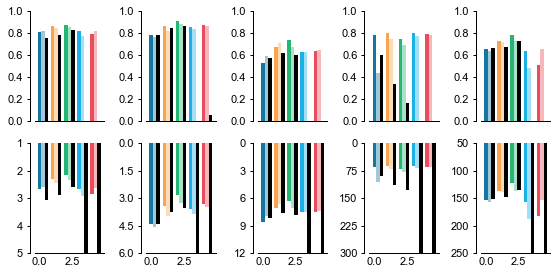

In [47]:
x_t = np.arange(5)
fig = plt.figure(figsize=((8/2.54)*3*2.5/3, (6/2.54)*2*2.5/3))
grid = plt.GridSpec(2,5)
for _ in range(5):
    ax0 = plt.subplot(grid[_])
    ax0.spines['right'].set_visible(False)
    ax0.spines['left'].set_position(('outward', 5))
    ax0.axes.xaxis.set_ticklabels([])
    ax0.tick_params(axis='x', length=0)

    expect3 = ax0.bar(x_t+(0.8/3), raw_r2_scores[:, _], width=0.8/3, color=[cmap[5], cmap[2], cmap[3], cmap[4], cmap[0]], alpha=0.4)
    expect1 = ax0.bar(x_t, tr_r2_scores[:, _], width=0.8/3, color=[cmap[5], cmap[2], cmap[3], cmap[4], cmap[0]])
    expect2 = ax0.bar(x_t+(0.8/3*2), prev_r2_scores[:, _], width=0.8/3, color='k')

    ax0.set_ybound([0, 1])
    ax0.yaxis.set_major_locator(LinearLocator(6))
    plt.xticks(rotation=45)

bounds = [[1, 5], [0, 6], [0, 12], [0, 300], [50, 250]]
loc = [5, 5, 5, 5, 5]
for _ in range(5): 
    ax0 = plt.subplot(grid[_+5])
    ax0.spines['right'].set_visible(False)
    ax0.spines['left'].set_position(('outward', 5))
    ax0.tick_params(axis='x', length=0)

    expect2 = ax0.bar(x_t+(0.8/3), raw_RMSEs[:, _], width=0.8/3, color=[cmap[5], cmap[2], cmap[3], cmap[4], cmap[0]], alpha=0.4)
    expect3 = ax0.bar(x_t+((0.8/3)*2), prev_RMSEs[:, _], width=0.8/3, color='k')
    expect1 = ax0.bar(x_t, tr_RMSEs[:, _], width=0.8/3, color=[cmap[5], cmap[2], cmap[3], cmap[4], cmap[0]])

    ax0.yaxis.set_major_locator(LinearLocator(loc[_]))
    ax0.set_ybound(bounds[_])
    ax0.invert_yaxis()
    plt.xticks(rotation=0)
    
fig.tight_layout()
fig.savefig('./figures/Fig8B.svg', transparent=True, format='svg')
plt.show()

NameError: name 'pap_r2' is not defined

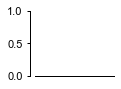

In [48]:
x_t = np.arange(5)
fig = plt.figure(figsize=((8/2.54)*1.8/1.8, (6/2.54)*2/1.8))
grid = plt.GridSpec(2,2)

ax0 = plt.subplot(grid[0])
ax0.spines['right'].set_visible(False)
ax0.spines['left'].set_position(('outward', 5))
ax0.axes.xaxis.set_ticklabels([])
ax0.tick_params(axis='x', length=0)

expect3 = ax0.bar(x_t+(0.8/3), pap_r2[1, :], width=0.8/3, color=[cmap[5], cmap[2], cmap[3], cmap[4], cmap[0]], alpha=0.4)
expect1 = ax0.bar(x_t, pap_r2[2, :], width=0.8/3, color=[cmap[5], cmap[2], cmap[3], cmap[4], cmap[0]])
expect2 = ax0.bar(x_t+(0.8/3*2), pap_r2[0, :], width=0.8/3, color='k')

ax0.set_ybound([0, 1])
ax0.yaxis.set_major_locator(LinearLocator(6))
plt.xticks(rotation=45)

ax0 = plt.subplot(grid[2])
ax0.spines['right'].set_visible(False)
ax0.spines['left'].set_position(('outward', 5))
ax0.tick_params(axis='x', length=0)

expect2 = ax0.bar(x_t+(0.8/3), pap_RMSEs[1, :], width=0.8/3, color=[cmap[5], cmap[2], cmap[3], cmap[4], cmap[0]], alpha=0.4)
expect3 = ax0.bar(x_t+((0.8/3)*2), pap_RMSEs[0, :], width=0.8/3, color='k')
expect1 = ax0.bar(x_t, pap_RMSEs[2, :], width=0.8/3, color=[cmap[5], cmap[2], cmap[3], cmap[4], cmap[0]])

ax0.yaxis.set_major_locator(LinearLocator(6))
ax0.set_ybound([0, 150])
ax0.invert_yaxis()
plt.xticks(rotation=0)


ax0 = plt.subplot(grid[1])
ax0.spines['right'].set_visible(False)
ax0.spines['left'].set_position(('outward', 5))
ax0.axes.xaxis.set_ticklabels([])
ax0.tick_params(axis='x', length=0)

expect3 = ax0.bar(x_t+(0.8/3), tom_r2[1, :], width=0.8/3, color=[cmap[5], cmap[2], cmap[3], cmap[4], cmap[0]], alpha=0.4)
expect1 = ax0.bar(x_t, tom_r2[2, :], width=0.8/3, color=[cmap[5], cmap[2], cmap[3], cmap[4], cmap[0]])
expect2 = ax0.bar(x_t+(0.8/3*2), tom_r2[0, :], width=0.8/3, color='k')

ax0.set_ybound([0, 1])
ax0.yaxis.set_major_locator(LinearLocator(6))
plt.xticks(rotation=45)

ax0 = plt.subplot(grid[3])
ax0.spines['right'].set_visible(False)
ax0.spines['left'].set_position(('outward', 5))
ax0.tick_params(axis='x', length=0)

expect2 = ax0.bar(x_t+(0.8/3), tom_RMSEs[1, :], width=0.8/3, color=[cmap[5], cmap[2], cmap[3], cmap[4], cmap[0]], alpha=0.4)
expect3 = ax0.bar(x_t+((0.8/3)*2), tom_RMSEs[0, :], width=0.8/3, color='k')
expect1 = ax0.bar(x_t, tom_RMSEs[2, :], width=0.8/3, color=[cmap[5], cmap[2], cmap[3], cmap[4], cmap[0]])

ax0.yaxis.set_major_locator(LinearLocator(5))
ax0.set_ybound([0, 100])
ax0.invert_yaxis()
plt.xticks(rotation=0)

fig.tight_layout()
fig.savefig('./figures/Fig7.svg', transparent=True, format='svg')
plt.show()

# Figure 8

### R2 & RMSE

In [49]:
test_label = pd.read_csv('./results/val_tr_test_label.csv', index_col='Unnamed: 0')
mlp_pred = pd.read_csv('./results/val_tr_mlp_pred.csv', index_col='Unnamed: 0')
lstm_pred = pd.read_csv('./results/val_tr_lstm_pred.csv', index_col='Unnamed: 0')
bilstm_pred = pd.read_csv('./results/val_tr_bilstm_pred.csv', index_col='Unnamed: 0')
ae_lstm_pred = pd.read_csv('./results/val_tr_ae_lstm_pred.csv', index_col='Unnamed: 0')
ae_bilstm_pred = pd.read_csv('./results/val_tr_ae_bilstm_pred.csv', index_col='Unnamed: 0')
pred_results = [mlp_pred, lstm_pred, bilstm_pred, ae_lstm_pred, ae_bilstm_pred]

In [50]:
r2_scores = []
for pred_ in pred_results:
    temp = []
    for i in range(5):
        temp.append(r2_score(test_label.values[..., i], pred_.values[..., i]))
    r2_scores.append(temp)
r2_scores = np.array(r2_scores)

RMSEs = []
for pred_ in pred_results:
    temp = []
    for i in range(5):
        temp.append(np.sqrt(mean_squared_error(test_label.values[..., i], pred_.values[..., i])))
    RMSEs.append(temp)
RMSEs = np.array(RMSEs)

In [51]:
tr_r2_scores = r2_scores
tr_RMSEs = RMSEs

In [52]:
mlp_pred = pd.read_csv('./results/val_raw_mlp_pred.csv', index_col='Unnamed: 0')
lstm_pred = pd.read_csv('./results/val_raw_lstm_pred.csv', index_col='Unnamed: 0')
bilstm_pred = pd.read_csv('./results/val_raw_bilstm_pred.csv', index_col='Unnamed: 0')
ae_lstm_pred = pd.read_csv('./results/val_raw_ae_lstm_pred.csv', index_col='Unnamed: 0')
ae_bilstm_pred = pd.read_csv('./results/val_raw_ae_bilstm_pred.csv', index_col='Unnamed: 0')
pred_results = [mlp_pred, lstm_pred, bilstm_pred, ae_lstm_pred, ae_bilstm_pred]

In [53]:
r2_scores = []
for pred_ in pred_results:
    temp = []
    for i in range(5):
        temp.append(r2_score(test_label.values[..., i], pred_.values[..., i]))
    r2_scores.append(temp)
r2_scores = np.array(r2_scores)

RMSEs = []
for pred_ in pred_results:
    temp = []
    for i in range(5):
        temp.append(np.sqrt(mean_squared_error(test_label.values[..., i], pred_.values[..., i])))
    RMSEs.append(temp)
RMSEs = np.array(RMSEs)

In [54]:
raw_r2_scores = r2_scores
raw_RMSEs = RMSEs

In [55]:
mlp_pred = pd.read_csv('./results/val_prev_mlp_pred.csv', index_col='Unnamed: 0')
lstm_pred = pd.read_csv('./results/val_prev_lstm_pred.csv', index_col='Unnamed: 0')
bilstm_pred = pd.read_csv('./results/val_prev_bilstm_pred.csv', index_col='Unnamed: 0')
ae_lstm_pred = pd.read_csv('./results/val_prev_ae_lstm_pred.csv', index_col='Unnamed: 0')
ae_bilstm_pred = pd.read_csv('./results/val_prev_ae_bilstm_pred.csv', index_col='Unnamed: 0')
pred_results = [mlp_pred, lstm_pred, bilstm_pred, ae_lstm_pred, ae_bilstm_pred]

In [56]:
ae_bilstm_pred

,T_in,T_out,RH_in,CO2,Rad
0,27.156954,1.796713,66.255790,2365.6038,782.52480
1,29.092150,1.844296,68.411130,2376.0369,797.53955
2,29.826048,1.707819,70.046360,2381.3025,808.96390
3,30.259598,1.248354,70.650750,2383.9243,815.08844
4,30.519514,0.779304,70.687350,2389.8308,818.46515
...,...,...,...,...,...
506011,28.109474,-0.242710,65.078130,2399.1829,799.49080
506012,28.497160,-0.383804,65.465740,2408.6013,801.19430
506013,29.043430,-0.622156,66.030685,2421.7900,804.44320
506014,30.243189,-1.311809,67.199234,2453.7573,816.80770


In [57]:
mlp_pred

,T_in,T_out,RH_in,CO2,Rad
0,17.801399,-2.559320,47.705066,700.809581,-41.689320
1,19.226738,-2.433758,43.062989,727.443868,-49.015782
2,19.869756,-2.791762,39.778846,751.250890,-55.879465
3,19.426283,-2.357509,44.446244,757.169574,-48.251023
4,19.057080,-2.571803,47.458766,764.817881,-44.320782
...,...,...,...,...,...
506011,17.482505,14.703198,80.875258,543.323543,400.817529
506012,17.053391,16.231623,78.864525,530.202282,289.875531
506013,18.734688,16.755020,81.969460,540.806761,338.970952
506014,18.392096,17.042946,86.591080,484.675972,158.530663


In [58]:
r2_scores = []
for pred_ in pred_results:
    temp = []
    for i in range(5):
        temp.append(r2_score(test_label.values[..., i], pred_.values[..., i]))
    r2_scores.append(temp)
r2_scores = np.array(r2_scores)

RMSEs = []
for pred_ in pred_results:
    temp = []
    for i in range(5):
        temp.append(np.sqrt(mean_squared_error(test_label.values[..., i], pred_.values[..., i])))
    RMSEs.append(temp)
RMSEs = np.array(RMSEs)

In [59]:
prev_r2_scores = r2_scores
prev_RMSEs = RMSEs

In [60]:
print(prev_r2_scores.mean(axis=1))
print(raw_r2_scores.mean(axis=1))
print(tr_r2_scores.mean(axis=1))
pap_r2 = np.array([prev_r2_scores.mean(axis=1), raw_r2_scores.mean(axis=1), tr_r2_scores.mean(axis=1)])

[  0.65439506   0.68512314   0.6492314  -33.41233177 -28.68089226]
[0.74370551 0.72520409 0.71330287 0.30330794 0.34362902]
[ 0.7208884   0.76374423  0.78095037  0.45602026 -0.03810493]


In [61]:
print(prev_RMSEs.mean(axis=1))
print(raw_RMSEs.mean(axis=1))
print(tr_RMSEs.mean(axis=1))
pap_RMSEs = np.array([prev_RMSEs.mean(axis=1), raw_RMSEs.mean(axis=1), tr_RMSEs.mean(axis=1)])

[ 57.75094136  57.14634977  58.33751662 569.50745167 530.84961778]
[51.99866223 53.67869224 55.42667271 82.42543371 82.40968637]
[ 54.4202997   50.73395962  48.71771852  77.24620697 104.11471496]


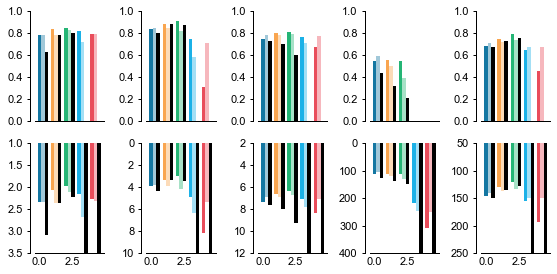

In [62]:
x_t = np.arange(5)
fig = plt.figure(figsize=((8/2.54)*3*2.5/3, (6/2.54)*2*2.5/3))
grid = plt.GridSpec(2,5)
for _ in range(5):
    ax0 = plt.subplot(grid[_])
    ax0.spines['right'].set_visible(False)
    ax0.spines['left'].set_position(('outward', 5))
    ax0.axes.xaxis.set_ticklabels([])
    ax0.tick_params(axis='x', length=0)

    expect3 = ax0.bar(x_t+(0.8/3), raw_r2_scores[:, _], width=0.8/3, color=[cmap[5], cmap[2], cmap[3], cmap[4], cmap[0]], alpha=0.4)
    expect1 = ax0.bar(x_t, tr_r2_scores[:, _], width=0.8/3, color=[cmap[5], cmap[2], cmap[3], cmap[4], cmap[0]])
    expect2 = ax0.bar(x_t+(0.8/3*2), prev_r2_scores[:, _], width=0.8/3, color='k')

    ax0.set_ybound([0, 1])
    ax0.yaxis.set_major_locator(LinearLocator(6))
    plt.xticks(rotation=45)

bounds = [[1, 3.5], [0, 10], [2, 12], [0, 400], [50, 250]]
loc = [6, 6, 6, 5, 5]
for _ in range(5): 
    ax0 = plt.subplot(grid[_+5])
    ax0.spines['right'].set_visible(False)
    ax0.spines['left'].set_position(('outward', 5))
    ax0.tick_params(axis='x', length=0)

    expect2 = ax0.bar(x_t+(0.8/3), raw_RMSEs[:, _], width=0.8/3, color=[cmap[5], cmap[2], cmap[3], cmap[4], cmap[0]], alpha=0.4)
    expect3 = ax0.bar(x_t+((0.8/3)*2), prev_RMSEs[:, _], width=0.8/3, color='k')
    expect1 = ax0.bar(x_t, tr_RMSEs[:, _], width=0.8/3, color=[cmap[5], cmap[2], cmap[3], cmap[4], cmap[0]])

    ax0.yaxis.set_major_locator(LinearLocator(loc[_]))
    ax0.set_ybound(bounds[_])
    ax0.invert_yaxis()
    plt.xticks(rotation=0)
    
fig.tight_layout()
fig.savefig('./figures/Fig8A.svg', transparent=True, format='svg')
plt.show()